<a href="https://colab.research.google.com/github/anjalidahiya5153/CodeReverse/blob/main/Vades_implementation_third.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sentence-transformers datasets spacy textstat joblib tqdm scikit-learn beautifulsoup4
!python -m spacy download en_core_web_sm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import os
import joblib
from collections import defaultdict, Counter
from tqdm import tqdm
import re
import string
import random

from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

import spacy
import textstat
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.4/176.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/final_year_project_books_folder"
BOOKS_DIR = os.path.join(DRIVE_ROOT, "gutenberg_books")
FEAT_CACHE_DIR = os.path.join(DRIVE_ROOT, "feat_cache_fixed")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "vades_checkpoints_fixed")
SPLIT_DIR = os.path.join(DRIVE_ROOT, "splits_fixed")
OUTPUT_CSV = os.path.join(DRIVE_ROOT, "gutenberg_dataset_clean.csv")

os.makedirs(FEAT_CACHE_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

In [ ]:
RND = 42
random.seed(RND)
np.random.seed(RND)
torch.manual_seed(RND)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✓ Setup complete")
print(f"Device: {device}")

✓ Setup complete
Device: cuda


In [ ]:
# ============================================================================
# STEP 1: Data Preprocessing
# ============================================================================

print("\n" + "="*80)
print("STEP 1: Preprocessing Gutenberg Books")
print("="*80)

def extract_text_from_html(file_path):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        soup = BeautifulSoup(f, "html.parser")
        for tag in soup(["table", "script", "style"]):
            tag.extract()
        text = soup.get_text(separator=" ", strip=True)
        return text

def clean_gutenberg_text(text: str) -> str:
    text = re.sub(r'(?is).*?(the project gutenberg ebook of )', '', text, count=1)
    text = re.sub(r'(?is)end of (the )?project gutenberg ebook.*', '', text)
    text = re.sub(r'(?is)\*\*\* *start of (the )?project gutenberg ebook.*?\*\*\*', '', text)
    text = re.sub(r'(?is)\*\*\* *end of (the )?project gutenberg ebook.*?\*\*\*', '', text)
    text = re.sub(r'(?i)(produced by|transcribed from|scanned by).*?\n', '', text)
    text = re.sub(r'\bCHAPTER\s+[A-Z0-9IVX]+\b', '', text)
    text = re.sub(r'\bChapter\s+\d+\b', '', text)
    text = re.sub(r'[_*#~]+', ' ', text)
    text = re.sub(r'-{2,}', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def chunk_text(text, chunk_size=3000, overlap=300):
    """Create chunks with overlap"""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]
        if len(chunk.split()) > 150:  # Only keep substantial chunks
            chunks.append(chunk)
        start += chunk_size - overlap
    return chunks

if os.path.exists(OUTPUT_CSV):
    print(f"✓ Found existing dataset: {OUTPUT_CSV}")
    df = pd.read_csv(OUTPUT_CSV)
    print(f"✓ Loaded {len(df)} text chunks from {df['author'].nunique()} authors")
else:
    print("Processing Gutenberg books from HTML files...")
    data = []

    for author in tqdm(os.listdir(BOOKS_DIR), desc="Processing authors"):
        author_folder = os.path.join(BOOKS_DIR, author)
        if not os.path.isdir(author_folder):
            continue

        for fname in os.listdir(author_folder):
            if not fname.endswith(".html"):
                continue

            file_path = os.path.join(author_folder, fname)
            try:
                raw_text = extract_text_from_html(file_path)
                cleaned_text = clean_gutenberg_text(raw_text)
                chunks = chunk_text(cleaned_text, chunk_size=3000, overlap=300)
                for i, chunk in enumerate(chunks):
                    if chunk.strip():
                        data.append({
                            "author": author,
                            "file_name": fname,
                            "chunk_id": i,
                            "text": chunk
                        })
            except Exception as e:
                print(f"⚠️ Error reading {file_path}: {e}")

    df = pd.DataFrame(data)
    print(f"✓ Loaded {len(df)} text chunks from {df['author'].nunique()} authors")
    df.to_csv(OUTPUT_CSV, index=False)
    print(f"✓ Dataset saved to: {OUTPUT_CSV}")

print(f"\nDataset shape: {df.shape}")
print(f"Authors: {df['author'].nunique()}")
print(f"Chunks per author: {df.groupby('author').size().describe()}")



STEP 1: Preprocessing Gutenberg Books
Processing Gutenberg books from HTML files...


Processing authors: 100%|██████████| 10/10 [01:24<00:00,  8.49s/it]


✓ Loaded 15198 text chunks from 10 authors
✓ Dataset saved to: /content/drive/MyDrive/final_year_project_books_folder/gutenberg_dataset_clean.csv

Dataset shape: (15198, 4)
Authors: 10
Chunks per author: count      10.000000
mean     1519.800000
std       827.069902
min       276.000000
25%      1145.000000
50%      1503.000000
75%      1791.500000
max      3154.000000
dtype: float64


In [ ]:
# ============================================================================
# FIX #2: SPLIT BY BOOKS FIRST (NO DATA LEAKAGE)
# ============================================================================

print("\n" + "="*80)
print("STEP 2: Creating Train/Val/Test Splits (BOOK-LEVEL)")
print("="*80)

# CREATE THE DIRECTORY FIRST!
os.makedirs(SPLIT_DIR, exist_ok=True)

train_csv = os.path.join(SPLIT_DIR, "train.csv")
val_csv = os.path.join(SPLIT_DIR, "val.csv")
test_csv = os.path.join(SPLIT_DIR, "test.csv")

if os.path.exists(train_csv) and os.path.exists(val_csv) and os.path.exists(test_csv):
    print("✓ Found existing splits, loading...")
    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)
    test_df = pd.read_csv(test_csv)
else:
    print("Creating new splits BY BOOK (no leakage)...")

    # CRITICAL: Split at BOOK level, not chunk level
    df['book_id'] = df['author'] + '___' + df['file_name']
    unique_books = df[['author', 'book_id']].drop_duplicates()

    # Split books 70/15/15
    train_books, temp_books = train_test_split(
        unique_books, test_size=0.3, stratify=unique_books['author'], random_state=RND
    )
    val_books, test_books = train_test_split(
        temp_books, test_size=0.5, stratify=temp_books['author'], random_state=RND
    )

    # Get chunks for each split
    train_df = df[df['book_id'].isin(train_books['book_id'])].reset_index(drop=True)
    val_df = df[df['book_id'].isin(val_books['book_id'])].reset_index(drop=True)
    test_df = df[df['book_id'].isin(test_books['book_id'])].reset_index(drop=True)

    # Verify no leakage
    train_books_set = set(train_df['book_id'])
    val_books_set = set(val_df['book_id'])
    test_books_set = set(test_df['book_id'])

    assert len(train_books_set & val_books_set) == 0, "❌ Data leakage: train/val overlap!"
    assert len(train_books_set & test_books_set) == 0, "❌ Data leakage: train/test overlap!"
    assert len(val_books_set & test_books_set) == 0, "❌ Data leakage: val/test overlap!"

    print(f"✓ No data leakage verified!")
    print(f"  Train books: {len(train_books_set)}")
    print(f"  Val books: {len(val_books_set)}")
    print(f"  Test books: {len(test_books_set)}")

    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)
    test_df.to_csv(test_csv, index=False)
    print(f"✓ Saved splits to {SPLIT_DIR}")

print(f"Train: {len(train_df)} chunks, Val: {len(val_df)} chunks, Test: {len(test_df)} chunks")
print(f"Authors in train: {train_df['author'].nunique()}")


STEP 2: Creating Train/Val/Test Splits (BOOK-LEVEL)
Creating new splits BY BOOK (no leakage)...
✓ No data leakage verified!
  Train books: 56
  Val books: 12
  Test books: 12
✓ Saved splits to /content/drive/MyDrive/final_year_project_books_folder/splits_fixed
Train: 10809 chunks, Val: 2454 chunks, Test: 1935 chunks
Authors in train: 10


In [ ]:
# ============================================================================
# STEP 3: Feature Extraction
# ============================================================================

print("\n" + "="*80)
print("STEP 3: Extracting 300-D Stylistic Features")
print("="*80)

nlp = spacy.load("en_core_web_sm", disable=["parser"])

FUNCTION_WORDS = [
    "the","be","to","of","and","a","in","that","have","i","it","for","not","on","with",
    "he","as","you","do","at","this","but","his","by","from","they","we","say","her","she",
    "or","an","will","my","one","all","would","there","their","what","so","up","out","if",
    "about","who","get","which","go","me","when","make","can","like","time","no","just","him",
    "know","take"
]
FW_K = 60

def basic_counts(text):
    chars = len(text)
    words = text.split()
    num_words = len(words)
    num_sents = max(1, len(re.split(r'[.!?]+', text)))
    avg_sent_len = num_words / num_sents if num_sents > 0 else 0
    avg_word_len = sum(len(w) for w in words) / max(1, num_words)
    return {"chars": chars, "num_words": num_words, "num_sents": num_sents,
            "avg_sent_len": avg_sent_len, "avg_word_len": avg_word_len}

def punctuation_ratios(text, norm):
    counts = Counter(ch for ch in text if ch in string.punctuation)
    keys = ['.',',',';','!','?',"'",'"',':','-','(',')']
    return [counts.get(k, 0) / max(1, norm) for k in keys]

def function_word_freqs(text, top_k=FW_K):
    words = [w.lower() for w in re.findall(r"\w+", text)]
    c = Counter(words)
    freqs = [c.get(fw, 0) / max(1, len(words)) for fw in FUNCTION_WORDS[:top_k]]
    if len(freqs) < top_k:
        freqs += [0.0] * (top_k - len(freqs))
    return freqs

def lexical_stats(text):
    words = [w for w in re.findall(r"\w+", text)]
    types = set(w.lower() for w in words)
    ttr = len(types) / max(1, len(words))
    hapax = sum(1 for _, cnt in Counter(words).items() if cnt == 1) / max(1, len(words))
    freqs = Counter(w.lower() for w in words)
    M1 = len(words)
    M2 = sum(v * v for v in freqs.values())
    yk = 10000.0 * (M2 - M1) / (M1 * M1) if M1 > 0 else 0.0
    return [ttr, hapax, yk]

def syllable_stats(text):
    try:
        sylls = textstat.syllable_count(text)
    except Exception:
        words = text.split()
        sylls = sum(max(1, sum(1 for ch in w if ch.lower() in 'aeiou')) for w in words)
    words = text.split()
    avg_syll = sylls / max(1, len(words))
    return [sylls, avg_syll]

def readability_feats(text):
    try:
        fre = textstat.flesch_reading_ease(text)
        fk = textstat.flesch_kincaid_grade(text)
        sm = textstat.smog_index(text)
        cli = textstat.coleman_liau_index(text)
    except Exception:
        fre, fk, sm, cli = 0.0, 0.0, 0.0, 0.0
    return [fre, fk, sm, cli]

def pos_ner_feats(text):
    doc = nlp(text)
    pos_counts = Counter([t.pos_ for t in doc])
    pos_keys = ['NOUN','VERB','ADJ','ADV','PRON','DET','ADP','NUM','PROPN','PART','INTJ','SYM','X','PUNCT']
    pos_freqs = [pos_counts.get(k, 0) / max(1, len(doc)) for k in pos_keys]

    ent_counts = Counter([ent.label_ for ent in doc.ents])
    ent_keys = ['PERSON','NORP','ORG','GPE','LOC','PRODUCT','EVENT','WORK_OF_ART','LAW','LANGUAGE','DATE','TIME','PERCENT','MONEY']
    ner_freqs = [ent_counts.get(k, 0) / max(1, len(doc)) for k in ent_keys]

    return pos_freqs + ner_freqs

def char_ngram_feats(text, n_range=(2, 4), top_k=50):
    s = re.sub(r'\s+', '', text.lower())
    counts = Counter()
    for n in range(n_range[0], n_range[1] + 1):
        for i in range(len(s) - n + 1):
            counts[s[i:i+n]] += 1
    most = [g for g, _ in counts.most_common(top_k)]
    total = max(1, sum(counts.values()))
    freqs = [counts.get(g, 0) / total for g in most]
    if len(freqs) < top_k:
        freqs += [0.0] * (top_k - len(freqs))
    return freqs

def word_ngram_feats(text, n=2, top_k=50):
    words = [w.lower() for w in re.findall(r"\w+", text)]
    counts = Counter()
    for i in range(len(words) - n + 1):
        gram = " ".join(words[i:i+n])
        counts[gram] += 1
    most = [g for g, _ in counts.most_common(top_k)]
    total = max(1, sum(counts.values()))
    freqs = [counts.get(g, 0) / total for g in most]
    if len(freqs) < top_k:
        freqs += [0.0] * (top_k - len(freqs))
    return freqs

def distributional_feats(text):
    words = [w.lower() for w in re.findall(r"\w+", text)]
    c = Counter(words)
    total = max(1, sum(c.values()))
    probs = np.array([v / total for v in c.values()], dtype=float)
    entropy = -np.sum(probs * np.log2(probs + 1e-12))
    top1 = max(c.values()) / total if total > 0 else 0.0
    return [entropy, top1]

def build_style_vector(text, target_dim=300):
    feats = []
    bc = basic_counts(text)
    feats += [bc["chars"], bc["num_words"], bc["num_sents"], bc["avg_sent_len"], bc["avg_word_len"]]
    feats += punctuation_ratios(text, bc["num_words"])
    feats += function_word_freqs(text, top_k=FW_K)
    feats += lexical_stats(text)
    feats += syllable_stats(text)
    feats += readability_feats(text)
    feats += pos_ner_feats(text)
    feats += char_ngram_feats(text, n_range=(2, 4), top_k=50)
    feats += word_ngram_feats(text, n=2, top_k=50)
    feats += distributional_feats(text)

    digits = sum(1 for ch in text if ch.isdigit()) / max(1, bc["chars"])
    uppercase_words = sum(1 for w in text.split() if w.isupper()) / max(1, bc["num_words"])
    stop_frac = sum(1 for w in re.findall(r"\w+", text.lower())
                    if w in spacy.lang.en.stop_words.STOP_WORDS) / max(1, bc["num_words"])
    feats += [digits, uppercase_words, stop_frac]

    if len(feats) < target_dim:
        feats += [0.0] * (target_dim - len(feats))
    else:
        feats = feats[:target_dim]

    return np.array(feats, dtype=np.float32)

print("✓ Feature extraction functions defined")



STEP 3: Extracting 300-D Stylistic Features
✓ Feature extraction functions defined


In [ ]:
# ============================================================================
# Compute and Cache Features
# ============================================================================

STYLE_DIM = 300
EMB_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMB_BATCH = 64

def compute_style_cache(df, cache_path, target_dim=300):
    if os.path.exists(cache_path):
        print(f"✓ Loading cached features: {cache_path}")
        return joblib.load(cache_path)

    print(f"Computing style features for {len(df)} samples...")
    texts = df['text'].tolist()
    feats = []

    for text in tqdm(texts, desc="Extracting style features"):
        if text and text.strip():
            vec = build_style_vector(text, target_dim=target_dim)
            feats.append(vec)
        else:
            feats.append(np.zeros(target_dim, dtype=np.float32))

    feats = np.stack(feats)
    joblib.dump(feats, cache_path)
    print(f"✓ Saved style cache: {cache_path}")
    return feats

train_feats = compute_style_cache(train_df, os.path.join(FEAT_CACHE_DIR, "train_feats.joblib"))
val_feats = compute_style_cache(val_df, os.path.join(FEAT_CACHE_DIR, "val_feats.joblib"))
test_feats = compute_style_cache(test_df, os.path.join(FEAT_CACHE_DIR, "test_feats.joblib"))

emb_model = SentenceTransformer(EMB_MODEL, device=device)

def compute_emb_cache(df, cache_path):
    if os.path.exists(cache_path):
        print(f"✓ Loading cached embeddings: {cache_path}")
        return joblib.load(cache_path)

    print(f"Computing embeddings for {len(df)} samples...")
    texts = df['text'].tolist()
    embs = emb_model.encode(texts, show_progress_bar=True,
                           convert_to_numpy=True, batch_size=EMB_BATCH)
    joblib.dump(embs, cache_path)
    print(f"✓ Saved embedding cache: {cache_path}")
    return embs

train_embs = compute_emb_cache(train_df, os.path.join(FEAT_CACHE_DIR, "train_embs.joblib"))
val_embs = compute_emb_cache(val_df, os.path.join(FEAT_CACHE_DIR, "val_embs.joblib"))
test_embs = compute_emb_cache(test_df, os.path.join(FEAT_CACHE_DIR, "test_embs.joblib"))

print(f"\n✓ Style features shape: {train_feats.shape}")
print(f"✓ Embeddings shape: {train_embs.shape}")

Computing style features for 10809 samples...


Extracting style features: 100%|██████████| 10809/10809 [18:10<00:00,  9.91it/s]


✓ Saved style cache: /content/drive/MyDrive/final_year_project_books_folder/feat_cache_fixed/train_feats.joblib
Computing style features for 2454 samples...


Extracting style features: 100%|██████████| 2454/2454 [04:00<00:00, 10.20it/s]


✓ Saved style cache: /content/drive/MyDrive/final_year_project_books_folder/feat_cache_fixed/val_feats.joblib
Computing style features for 1935 samples...


...

✓ Saved embedding cache: /content/drive/MyDrive/final_year_project_books_folder/feat_cache_fixed/train_embs.joblib
Computing embeddings for 2454 samples...


Batches:   0%|          | 0/39 [00:00<?, ?it/s]

✓ Saved embedding cache: /content/drive/MyDrive/final_year_project_books_folder/feat_cache_fixed/val_embs.joblib
Computing embeddings for 1935 samples...


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

✓ Saved embedding cache: /content/drive/MyDrive/final_year_project_books_folder/feat_cache_fixed/test_embs.joblib

✓ Style features shape: (10809, 300)
✓ Embeddings shape: (10809, 384)


In [ ]:
# ============================================================================
# VADES Model Definition
# ============================================================================

print("\n" + "="*80)
print("STEP 4: Defining VADES Model")
print("="*80)

class VADESModel(nn.Module):
    def __init__(self, emb_dim=384, style_dim=300, hidden_dim=512, num_authors=None):
        super().__init__()

        self.emb_dim = emb_dim
        self.style_dim = style_dim

        # Document encoder
        self.doc_encoder = nn.Sequential(
            nn.Linear(emb_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.Tanh()
        )

        self.doc_mean = nn.Sequential(
            nn.Linear(hidden_dim, style_dim),
            nn.Tanh()
        )

        self.doc_logvar = nn.Linear(hidden_dim, style_dim)

        # Author embeddings
        if num_authors:
            self.author_mean = nn.Embedding(num_authors, style_dim)
            self.author_logvar = nn.Embedding(num_authors, style_dim)
            nn.init.normal_(self.author_mean.weight, 0, 0.1)
            nn.init.constant_(self.author_logvar.weight, -1.0)

        # Contrastive loss parameters
        self.c_a = nn.Parameter(torch.tensor(1.0))
        self.e_a = nn.Parameter(torch.tensor(0.0))
        self.c_f = nn.Parameter(torch.tensor(1.0))
        self.e_f = nn.Parameter(torch.tensor(0.0))

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode_document(self, emb):
        h = self.doc_encoder(emb)
        return self.doc_mean(h), self.doc_logvar(h)

    def encode_author(self, author_ids):
        return self.author_mean(author_ids), self.author_logvar(author_ids)

    def forward(self, doc_emb, author_ids=None, num_samples=10):
        mu_d, logvar_d = self.encode_document(doc_emb)

        z_d_samples = torch.stack([
            self.reparameterize(mu_d, logvar_d) for _ in range(num_samples)
        ])

        if author_ids is not None:
            mu_a, logvar_a = self.encode_author(author_ids)
            z_a_samples = torch.stack([
                self.reparameterize(mu_a, logvar_a) for _ in range(num_samples)
            ])
            return z_d_samples, mu_d, logvar_d, z_a_samples, mu_a, logvar_a

        return z_d_samples, mu_d, logvar_d

    def get_document_embedding(self, doc_emb):
        mu_d, _ = self.encode_document(doc_emb)
        return mu_d

    def get_author_embedding(self, author_id):
        mu_a, _ = self.encode_author(author_id)
        return mu_a


def soft_contrastive_prob(z1, z2, c, e):
    dist_sq = torch.sum((z1 - z2) ** 2, dim=-1)
    return torch.sigmoid(-c * dist_sq + e)


def kl_divergence(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def vades_loss(model, doc_emb, author_ids, style_feats,
               neg_author_ids=None, neg_style_feats=None,
               alpha=0.1, beta=1e-5, num_samples=10):
    """
    CORRECTED loss function with proper negative sampling
    """
    batch_size = doc_emb.size(0)

    # Forward pass
    z_d, mu_d, logvar_d, z_a, mu_a, logvar_a = model(doc_emb, author_ids, num_samples)

    # ===== Author Loss =====
    pos_prob_a = soft_contrastive_prob(z_a, z_d, model.c_a, model.e_a)
    pos_log_prob_a = torch.log(pos_prob_a + 1e-8).mean(0)

    if neg_author_ids is not None:
        k_neg = neg_author_ids.size(1)
        neg_mu_a, neg_logvar_a = model.encode_author(neg_author_ids.view(-1))
        neg_mu_a = neg_mu_a.view(batch_size, k_neg, -1)
        neg_logvar_a = neg_logvar_a.view(batch_size, k_neg, -1)
        neg_z_a = model.reparameterize(neg_mu_a, neg_logvar_a)

        z_d_exp = z_d.unsqueeze(2)
        neg_z_a_exp = neg_z_a.unsqueeze(0)
        neg_prob_a = soft_contrastive_prob(neg_z_a_exp, z_d_exp, model.c_a, model.e_a)
        neg_log_prob_a = torch.log(1 - neg_prob_a + 1e-8).mean(0).sum(1)

        author_loss = -(pos_log_prob_a + neg_log_prob_a).mean()
    else:
        author_loss = -pos_log_prob_a.mean()

    # ===== Feature Loss =====
    style_feats_exp = style_feats.unsqueeze(0).expand(num_samples, -1, -1)
    pos_prob_f = soft_contrastive_prob(z_d, style_feats_exp, model.c_f, model.e_f)
    pos_log_prob_f = torch.log(pos_prob_f + 1e-8).mean(0)

    if neg_style_feats is not None:
        k_neg = neg_style_feats.size(1)
        neg_feats_exp = neg_style_feats.unsqueeze(0)
        z_d_exp = z_d.unsqueeze(2)
        neg_prob_f = soft_contrastive_prob(z_d_exp, neg_feats_exp, model.c_f, model.e_f)
        neg_log_prob_f = torch.log(1 - neg_prob_f + 1e-8).mean(0).sum(1)

        feature_loss = -(pos_log_prob_f + neg_log_prob_f).mean()
    else:
        feature_loss = -pos_log_prob_f.mean()

    # ===== KL Divergence =====
    kl_a = kl_divergence(mu_a, logvar_a)
    kl_d = kl_divergence(mu_d, logvar_d)
    kl_loss = kl_a + kl_d

    # ===== Total Loss =====
    total_loss = (1 - alpha) * author_loss + alpha * feature_loss + beta * kl_loss

    return total_loss, author_loss, feature_loss, kl_loss

print("✓ Model and loss functions defined")


STEP 4: Defining VADES Model
✓ Model and loss functions defined


In [ ]:
# ============================================================================
# Dataset and DataLoaders
# ============================================================================

class VADESDataset(Dataset):
    def __init__(self, embeddings, style_features, author_ids):
        self.embeddings = torch.FloatTensor(embeddings)
        self.style_features = torch.FloatTensor(style_features)
        self.author_ids = torch.LongTensor(author_ids)

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.style_features[idx], self.author_ids[idx]

print("Creating author mapping...")

author2id = {}
for author in sorted(train_df['author'].unique()):
    author2id[author] = len(author2id)

id2author = {v: k for k, v in author2id.items()}
num_authors = len(author2id)

print(f"✓ Created mapping for {num_authors} authors")

train_author_ids = np.array([author2id[a] for a in train_df['author']])
val_author_ids = np.array([author2id.get(a, -1) for a in val_df['author']])
test_author_ids = np.array([author2id.get(a, -1) for a in test_df['author']])

# Filter validation and test
val_mask = val_author_ids >= 0
val_embs_filtered = val_embs[val_mask]
val_feats_filtered = val_feats[val_mask]
val_author_ids_filtered = val_author_ids[val_mask]

test_mask = test_author_ids >= 0
test_embs_filtered = test_embs[test_mask]
test_feats_filtered = test_feats[test_mask]
test_author_ids_filtered = test_author_ids[test_mask]

print(f"\n✓ Data filtered:")
print(f"  • Train: {len(train_author_ids)} samples")
print(f"  • Val: {len(val_author_ids_filtered)} samples")
print(f"  • Test: {len(test_author_ids_filtered)} samples")

# Create datasets
train_dataset = VADESDataset(train_embs, train_feats, train_author_ids)
val_dataset = VADESDataset(val_embs_filtered, val_feats_filtered, val_author_ids_filtered)
test_dataset = VADESDataset(test_embs_filtered, test_feats_filtered, test_author_ids_filtered)

# FIX #3: BATCH_SIZE = 8 (not 32)
BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"\n✓ DataLoaders created with BATCH_SIZE={BATCH_SIZE}:")
print(f"  • train_loader: {len(train_loader)} batches")
print(f"  • val_loader: {len(val_loader)} batches")
print(f"  • test_loader: {len(test_loader)} batches")

Creating author mapping...
✓ Created mapping for 10 authors

✓ Data filtered:
  • Train: 10809 samples
  • Val: 2454 samples
  • Test: 1935 samples

✓ DataLoaders created with BATCH_SIZE=8:
  • train_loader: 1352 batches
  • val_loader: 307 batches
  • test_loader: 242 batches


In [ ]:
# ============================================================================
# FIX #6: SEPARATE LEARNING RATES
# ============================================================================

print("\n" + "="*80)
print("STEP 5: Initializing Model with Separate Learning Rates")
print("="*80)

model = VADESModel(
    emb_dim=384,
    style_dim=300,
    hidden_dim=512,
    num_authors=num_authors
).to(device)

# Separate learning rates: author embeddings need higher LR
author_params = [model.author_mean.weight, model.author_logvar.weight]
other_params = [p for n, p in model.named_parameters()
                if 'author_mean' not in n and 'author_logvar' not in n]

optimizer = optim.Adam([
    {'params': author_params, 'lr': 1e-3},      # Higher LR for author embeddings
    {'params': other_params, 'lr': 1e-4}        # Standard LR for encoder
])

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Model initialized on {device}")
print(f"✓ Total parameters: {total_params:,}")
print(f"✓ Separate learning rates:")
print(f"  • Author embeddings: 1e-3")
print(f"  • Encoder network: 1e-4")



STEP 5: Initializing Model with Separate Learning Rates
✓ Model initialized on cuda
✓ Total parameters: 775,628
✓ Separate learning rates:
  • Author embeddings: 1e-3
  • Encoder network: 1e-4



STEP 6: Training VADES (CORRECTED)
✓ Checkpoint directory: /content/drive/MyDrive/final_year_project_books_folder/vades_checkpoints_fixed

Training Configuration (CORRECTED):
  - Epochs: 50 (was 15)
  - Batch size: 8 (was 32)
  - Alpha (α): 0.1 (was 0.5)
  - Beta (β): 1e-05 (was 1e-3)
  - Negative samples (k): 5
  - Monte Carlo samples (L): 10
  - Training batches per epoch: 1352



Epoch 1/50 [Train]: 100%|██████████| 1352/1352 [00:24<00:00, 55.37it/s, loss=18.4207, auth=18.4207, feat=18.4207, kl=0.0691]



Epoch 1/50 Summary:
  Train - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0876
  Val   - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0818
  ✅ Saved best model to /content/drive/MyDrive/final_year_project_books_folder/vades_checkpoints_fixed/vades_best.pth (loss=18.4207)
--------------------------------------------------------------------------------


Epoch 2/50 [Train]: 100%|██████████| 1352/1352 [00:22<00:00, 60.93it/s, loss=18.4207, auth=18.4207, feat=18.4207, kl=0.0406]



Epoch 2/50 Summary:
  Train - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0646
  Val   - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0627
  ✅ Saved best model to /content/drive/MyDrive/final_year_project_books_folder/vades_checkpoints_fixed/vades_best.pth (loss=18.4207)
--------------------------------------------------------------------------------


...


Epoch 48/50 Summary:
  Train - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0004
  Val   - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0001
--------------------------------------------------------------------------------


Epoch 49/50 [Train]: 100%|██████████| 1352/1352 [00:22<00:00, 59.70it/s, loss=18.4207, auth=18.4207, feat=18.4207, kl=0.0005]



Epoch 49/50 Summary:
  Train - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0004
  Val   - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0001
--------------------------------------------------------------------------------


Epoch 50/50 [Train]: 100%|██████████| 1352/1352 [00:21<00:00, 61.49it/s, loss=18.4207, auth=18.4207, feat=18.4207, kl=0.0002]


  Validation Accuracy: 6.11%

Epoch 50/50 Summary:
  Train - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0003
  Val   - Total: 18.4207 | Author: 18.4207 | Feature: 18.4207 | KL: 0.0001
--------------------------------------------------------------------------------

✅ Training complete!
Best validation loss: 18.4207
✅ Saved training curves to /content/drive/MyDrive/final_year_project_books_folder/vades_checkpoints_fixed/training_curves.png


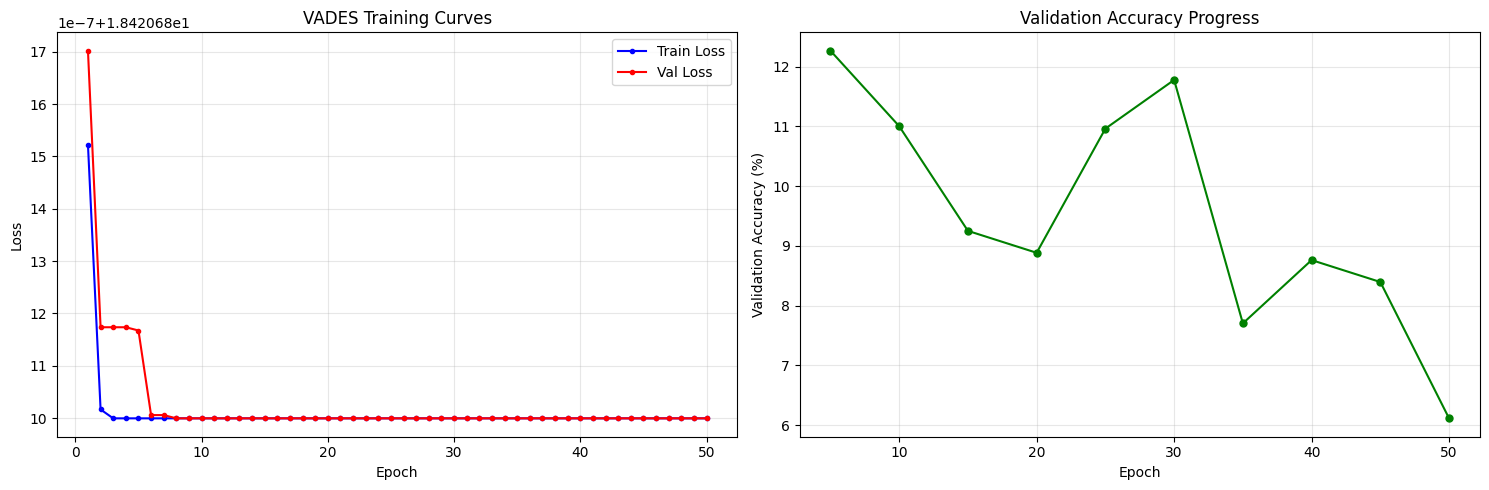

In [ ]:
# ============================================================================
# FIX #4: NUM_EPOCHS = 50 (not 15)
# FIX #1: ALPHA = 0.1 (not 0.5)
# FIX #7: Better negative sampling
# ============================================================================

print("\n" + "="*80)
print("STEP 6: Training VADES (CORRECTED)")
print("="*80)

# CRITICAL: Ensure checkpoint directory exists
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"✓ Checkpoint directory: {CHECKPOINT_DIR}")

# FIX #4: More epochs for small dataset
NUM_EPOCHS = 50

# FIX #1: Lower alpha for authorship focus
ALPHA = 0.1  # Changed from 0.5

# FIX: Better beta for small dataset
BETA = 1e-5  # Changed from 1e-3

K_NEG = 5
NUM_MC_SAMPLES = 10

best_val_loss = float('inf')
best_val_acc = 0.0

print(f"\nTraining Configuration (CORRECTED):")
print(f"  - Epochs: {NUM_EPOCHS} (was 15)")
print(f"  - Batch size: {BATCH_SIZE} (was 32)")
print(f"  - Alpha (α): {ALPHA} (was 0.5)")
print(f"  - Beta (β): {BETA} (was 1e-3)")
print(f"  - Negative samples (k): {K_NEG}")
print(f"  - Monte Carlo samples (L): {NUM_MC_SAMPLES}")
print(f"  - Training batches per epoch: {len(train_loader)}\n")

train_loss_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(NUM_EPOCHS):
    # ===== Training Phase =====
    model.train()
    train_losses = []
    train_author_losses = []
    train_feature_losses = []
    train_kl_losses = []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch_idx, (doc_emb, style_feat, author_id) in enumerate(pbar):
        doc_emb = doc_emb.to(device)
        style_feat = style_feat.to(device)
        author_id = author_id.to(device)

        batch_size = doc_emb.size(0)

        # FIX: Skip batch size of 1 (BatchNorm fails)
        if batch_size == 1:
            continue

        # FIX #7: Better negative sampling - ensure truly different authors
        neg_author_ids = []
        for i in range(batch_size):
            neg_ids = []
            for _ in range(K_NEG):
                neg_id = torch.randint(0, num_authors, (1,), device=device).item()
                while neg_id == author_id[i].item():
                    neg_id = torch.randint(0, num_authors, (1,), device=device).item()
                neg_ids.append(neg_id)
            neg_author_ids.append(neg_ids)
        neg_author_ids = torch.tensor(neg_author_ids, device=device)

        # Better negative style features - FIXED: use CPU indices
        rand_indices = torch.randint(0, len(train_dataset), (batch_size, K_NEG))  # Keep on CPU
        neg_style_feats = torch.stack([
            train_dataset.style_features[rand_indices[:, k]]  # Index on CPU
            for k in range(K_NEG)
        ], dim=1).to(device)  # Move to device AFTER stacking

        optimizer.zero_grad()
        total_loss, author_loss, feature_loss, kl_loss = vades_loss(
            model, doc_emb, author_id, style_feat,
            neg_author_ids, neg_style_feats,
            alpha=ALPHA, beta=BETA, num_samples=NUM_MC_SAMPLES
        )

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_losses.append(total_loss.item())
        train_author_losses.append(author_loss.item())
        train_feature_losses.append(feature_loss.item())
        train_kl_losses.append(kl_loss.item())

        pbar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'auth': f'{author_loss.item():.4f}',
            'feat': f'{feature_loss.item():.4f}',
            'kl': f'{kl_loss.item():.4f}'
        })

    avg_train_loss = np.mean(train_losses)
    avg_train_author = np.mean(train_author_losses)
    avg_train_feature = np.mean(train_feature_losses)
    avg_train_kl = np.mean(train_kl_losses)
    train_loss_history.append(avg_train_loss)

    # ===== Validation Phase =====
    model.eval()
    val_losses = []
    val_author_losses = []
    val_feature_losses = []
    val_kl_losses = []

    with torch.no_grad():
        for doc_emb, style_feat, author_id in val_loader:
            doc_emb = doc_emb.to(device)
            style_feat = style_feat.to(device)
            author_id = author_id.to(device)

            batch_size = doc_emb.size(0)

            # Skip batch size of 1 in validation too
            if batch_size == 1:
                continue

            total_loss, author_loss, feature_loss, kl_loss = vades_loss(
                model, doc_emb, author_id, style_feat,
                neg_author_ids=None, neg_style_feats=None,
                alpha=ALPHA, beta=BETA, num_samples=NUM_MC_SAMPLES
            )

            val_losses.append(total_loss.item())
            val_author_losses.append(author_loss.item())
            val_feature_losses.append(feature_loss.item())
            val_kl_losses.append(kl_loss.item())

    avg_val_loss = np.mean(val_losses)
    avg_val_author = np.mean(val_author_losses)
    avg_val_feature = np.mean(val_feature_losses)
    avg_val_kl = np.mean(val_kl_losses)
    val_loss_history.append(avg_val_loss)

    # ===== Quick validation accuracy (every 5 epochs) =====
    if (epoch + 1) % 5 == 0:
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for doc_emb, _, author_id in val_loader:
                doc_emb = doc_emb.to(device)
                author_id = author_id.to(device)

                # Get document embeddings
                mu_d = model.get_document_embedding(doc_emb)

                # FIX #5: Use MODEL author embeddings (not doc averages)
                all_author_ids = torch.arange(num_authors, device=device)
                author_embs = model.get_author_embedding(all_author_ids)

                # Find nearest author
                for i in range(len(mu_d)):
                    doc_emb_single = mu_d[i].unsqueeze(0)
                    distances = torch.cdist(doc_emb_single, author_embs).squeeze()
                    pred_author = torch.argmin(distances).item()

                    if pred_author == author_id[i].item():
                        correct += 1
                    total += 1

        val_acc = correct / total if total > 0 else 0.0
        val_acc_history.append(val_acc)
        print(f"  Validation Accuracy: {val_acc*100:.2f}%")

    # ===== Logging =====
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} Summary:")
    print(f"  Train - Total: {avg_train_loss:.4f} | Author: {avg_train_author:.4f} | Feature: {avg_train_feature:.4f} | KL: {avg_train_kl:.4f}")
    print(f"  Val   - Total: {avg_val_loss:.4f} | Author: {avg_val_author:.4f} | Feature: {avg_val_feature:.4f} | KL: {avg_val_kl:.4f}")

    # ===== Save Best Model =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'vades_best.pth')

        # Double-check directory exists before saving
        os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'train_loss': avg_train_loss,
            'config': {
                'alpha': ALPHA,
                'beta': BETA,
                'k_neg': K_NEG,
                'num_mc_samples': NUM_MC_SAMPLES,
                'batch_size': BATCH_SIZE,
                'num_epochs': NUM_EPOCHS
            }
        }, checkpoint_path)
        print(f"  ✅ Saved best model to {checkpoint_path} (loss={avg_val_loss:.4f})")

    print("-" * 80)

print("\n✅ Training complete!")
print(f"Best validation loss: {best_val_loss:.4f}")

# Plot training curves
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, 'b-o', label='Train Loss', markersize=3)
    plt.plot(range(1, len(val_loss_history) + 1), val_loss_history, 'r-o', label='Val Loss', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VADES Training Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)

    if val_acc_history:
        plt.subplot(1, 2, 2)
        epochs_acc = list(range(5, 5 * len(val_acc_history) + 1, 5))
        plt.plot(epochs_acc, [acc*100 for acc in val_acc_history], 'g-o', markersize=5)
        plt.xlabel('Epoch')
        plt.ylabel('Validation Accuracy (%)')
        plt.title('Validation Accuracy Progress')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()

    # Ensure directory exists for saving plot
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    curve_path = os.path.join(CHECKPOINT_DIR, 'training_curves.png')
    plt.savefig(curve_path, dpi=150)
    print(f"✅ Saved training curves to {curve_path}")
    plt.show()
except Exception as e:
    print(f"⚠️ Could not plot training curves: {e}")

✅ Saved training curves to /content/drive/MyDrive/final_year_project_books_folder/vades_checkpoints_fixed/training_curves.png


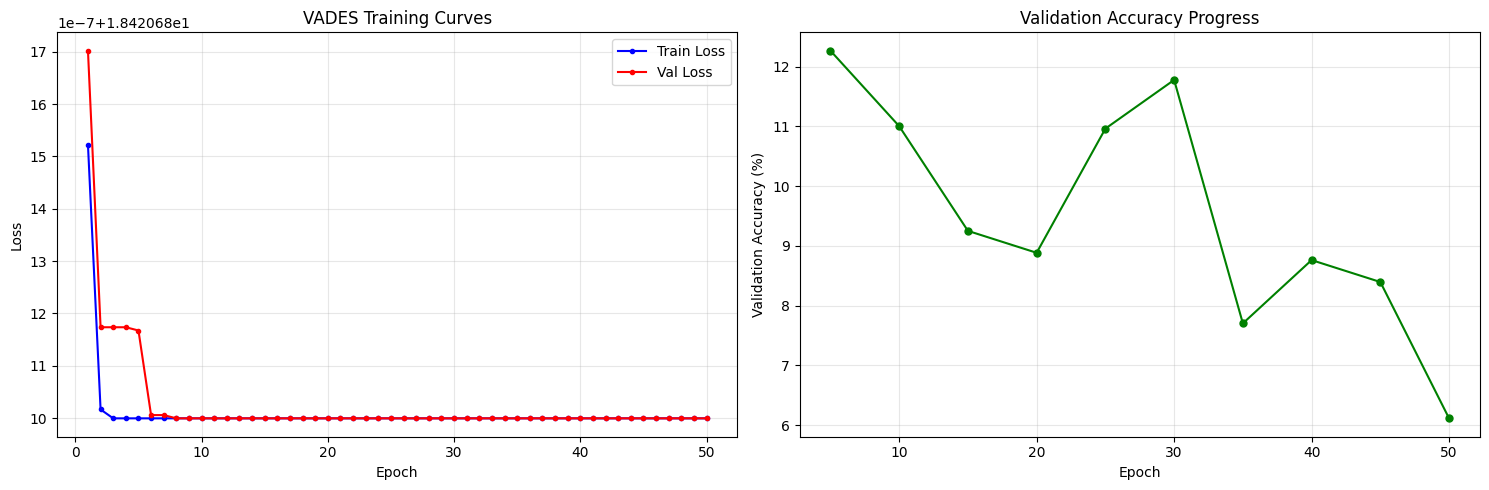

In [ ]:
# Plot training curves
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, NUM_EPOCHS + 1), train_loss_history, 'b-o', label='Train Loss', markersize=3)
    plt.plot(range(1, NUM_EPOCHS + 1), val_loss_history, 'r-o', label='Val Loss', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VADES Training Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)

    if val_acc_history:
        plt.subplot(1, 2, 2)
        epochs_acc = list(range(5, NUM_EPOCHS + 1, 5))
        plt.plot(epochs_acc, [acc*100 for acc in val_acc_history], 'g-o', markersize=5)
        plt.xlabel('Epoch')
        plt.ylabel('Validation Accuracy (%)')
        plt.title('Validation Accuracy Progress')
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    curve_path = os.path.join(CHECKPOINT_DIR, 'training_curves.png')
    plt.savefig(curve_path, dpi=150)
    print(f"✅ Saved training curves to {curve_path}")
    plt.show()
except:
    print("⚠️ Could not plot training curves")


In [ ]:
# ============================================================================
# FIX #5: EVALUATION - Use MODEL author embeddings
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: Authorship Attribution (CORRECTED)")
print("="*80)

# Load best model
checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR, 'vades_best.pth'),
    map_location=device,
    weights_only=False
)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")

model.eval()

# FIX #5: Use MODEL's learned author embeddings (not document averages)
print("\n🔍 Using MODEL's learned author embeddings (not doc averages)")

with torch.no_grad():
    all_author_ids = torch.arange(num_authors, device=device)
    author_embeddings = model.get_author_embedding(all_author_ids).cpu().numpy()

print(f"✅ Author embeddings shape: {author_embeddings.shape}")



EVALUATION: Authorship Attribution (CORRECTED)
✓ Loaded best model from epoch 7

🔍 Using MODEL's learned author embeddings (not doc averages)
✅ Author embeddings shape: (10, 300)


In [ ]:
# Test on test set
correct = 0
total = 0

with torch.no_grad():
    for doc_emb, _, author_id in tqdm(test_loader, desc="Testing"):
        doc_emb = doc_emb.to(device)
        mu_d = model.get_document_embedding(doc_emb).cpu().numpy()

        for i, true_aid in enumerate(author_id.numpy()):
            emb = mu_d[i]

            # Find nearest author by L2 distance
            distances = np.linalg.norm(author_embeddings - emb, axis=1)
            pred_aid = np.argmin(distances)

            if pred_aid == true_aid:
                correct += 1
            total += 1

accuracy = correct / total if total > 0 else 0.0

print("\n" + "="*80)
print(f"AUTHORSHIP ATTRIBUTION ACCURACY: {accuracy*100:.2f}% ({correct}/{total})")
print(f"Random baseline: {100/num_authors:.2f}%")
print(f"Improvement over random: {(accuracy - 1/num_authors)*100:.2f}%")
print("="*80)

Testing: 100%|██████████| 242/242 [00:00<00:00, 1009.64it/s]


AUTHORSHIP ATTRIBUTION ACCURACY: 13.28% (257/1935)
Random baseline: 10.00%
Improvement over random: 3.28%


In [ ]:
# ============================================================================
# Stylistic Feature Prediction
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: Stylistic Feature Prediction")
print("="*80)

model.eval()

test_embeddings = []
test_style_feats_array = []

with torch.no_grad():
    for doc_emb, style_feat, _ in tqdm(test_loader, desc="Extracting embeddings"):
        doc_emb = doc_emb.to(device)
        mu_d = model.get_document_embedding(doc_emb)
        test_embeddings.append(mu_d.cpu().numpy())
        test_style_feats_array.append(style_feat.numpy())

test_embeddings = np.vstack(test_embeddings)
test_style_feats_array = np.vstack(test_style_feats_array)

print(f"✓ Embeddings shape: {test_embeddings.shape}")
print(f"✓ Style features shape: {test_style_feats_array.shape}")

feature_groups = {
    'Structural': list(range(0, 5)),
    'Punctuation': list(range(5, 16)),
    'Function_words': list(range(16, 76)),
    'Lexical': list(range(76, 79)),
    'Syllables': list(range(79, 81)),
    'Readability': list(range(81, 85)),
    'TAG': list(range(85, 99)),
    'NER': list(range(99, 113)),
    'Char_ngrams': list(range(113, 163)),
    'Word_ngrams': list(range(163, 213)),
    'Distributional': list(range(213, 215)),
    'Extra': list(range(215, 218)),
}

mse_scores = {}
CV_FOLDS = 5  # Reduced for small dataset

for group_name, feat_indices in feature_groups.items():
    if not feat_indices or max(feat_indices) >= test_style_feats_array.shape[1]:
        continue

    group_mses = []

    for feat_idx in tqdm(feat_indices, desc=f"SVR for {group_name}", leave=False):
        y = test_style_feats_array[:, feat_idx]

        if y.std() < 1e-8:
            continue

        y_mean, y_std = y.mean(), y.std() + 1e-8
        y_norm = (y - y_mean) / y_std

        svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

        try:
            scores = cross_val_score(svr, test_embeddings, y_norm,
                                    cv=min(CV_FOLDS, len(y_norm)//2),
                                    scoring='neg_mean_squared_error',
                                    n_jobs=-1)
            mse = -scores.mean()
            group_mses.append(mse)
        except Exception as e:
            continue

    if group_mses:
        mse_scores[group_name] = (np.mean(group_mses), np.std(group_mses))

print("\n" + "="*80)
print("STYLISTIC FEATURE PREDICTION RESULTS (MSE ± std)")
print("="*80)
for group, (mean_mse, std_mse) in mse_scores.items():
    print(f"{group:20s}: {mean_mse:.3f} ± {std_mse:.3f}")

avg_mse = np.mean([v[0] for v in mse_scores.values()])
print(f"\nAverage MSE: {avg_mse:.3f}")


EVALUATION: Stylistic Feature Prediction


Extracting embeddings: 100%|██████████| 242/242 [00:00<00:00, 1306.84it/s]


✓ Embeddings shape: (1935, 300)
✓ Style features shape: (1935, 300)



STYLISTIC FEATURE PREDICTION RESULTS (MSE ± std)
Structural          : 1.071 ± 0.077
Punctuation         : 1.055 ± 0.033
Function_words      : 0.982 ± 0.094
Lexical             : 0.913 ± 0.120
Syllables           : 1.046 ± 0.054
Readability         : 1.002 ± 0.048
TAG                 : 0.921 ± 0.111
NER                 : 0.997 ± 0.097
Char_ngrams         : 0.977 ± 0.031
Word_ngrams         : 0.995 ± 0.038
Distributional      : 0.757 ± 0.092
Extra               : 0.988 ± 0.058

Average MSE: 0.975


In [ ]:
# ============================================================================
# Save Final Results
# ============================================================================

print("\n" + "="*80)
print("Saving Final Results")
print("="*80)

results = {
    'config': {
        'emb_dim': 384,
        'style_dim': 300,
        'hidden_dim': 512,
        'num_authors': num_authors,
        'alpha': ALPHA,
        'beta': BETA,
        'k_neg': K_NEG,
        'num_epochs': NUM_EPOCHS,
        'num_mc_samples': NUM_MC_SAMPLES,
        'batch_size': BATCH_SIZE,
        'learning_rates': {'author': 1e-3, 'encoder': 1e-4},
    },
    'training': {
        'best_val_loss': best_val_loss,
        'train_loss_history': train_loss_history,
        'val_loss_history': val_loss_history,
    },
    'evaluation': {
        'style_mse_scores': mse_scores,
        'authorship_accuracy': accuracy,
        'num_test_samples': len(test_dataset),
        'num_train_samples': len(train_dataset),
    },
}

results_path = os.path.join(CHECKPOINT_DIR, 'vades_results.joblib')
joblib.dump(results, results_path)
print(f"✅ Saved results to: {results_path}")

import json
results_json_path = os.path.join(CHECKPOINT_DIR, 'vades_results.json')
results_json = {
    'config': results['config'],
    'training': {
        'best_val_loss': float(best_val_loss),
        'final_train_loss': float(train_loss_history[-1]) if train_loss_history else None,
        'final_val_loss': float(val_loss_history[-1]) if val_loss_history else None,
    },
    'evaluation': {
        'style_mse_scores': {k: {'mean': float(v[0]), 'std': float(v[1])}
                            for k, v in mse_scores.items()},
        'authorship_accuracy': float(accuracy),
        'authorship_correct': int(correct),
        'authorship_total': int(total),
        'num_test_samples': len(test_dataset),
        'num_train_samples': len(train_dataset),
    },
}

with open(results_json_path, 'w') as f:
    json.dump(results_json, f, indent=2)
print(f"✅ Saved readable results to: {results_json_path}")

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

print(f"\n📊 Dataset Statistics:")
print(f"  • Number of authors: {num_authors}")
print(f"  • Training samples: {len(train_dataset)}")
print(f"  • Validation samples: {len(val_dataset)}")
print(f"  • Test samples: {len(test_dataset)}")

print(f"\n⚙️ Model Configuration (CORRECTED):")
print(f"  • Alpha: {ALPHA} (was 0.5)")
print(f"  • Batch size: {BATCH_SIZE} (was 32)")
print(f"  • Epochs: {NUM_EPOCHS} (was 15)")
print(f"  • Beta: {BETA} (was 1e-3)")
print(f"  • Learning rates: author=1e-3, encoder=1e-4")

print(f"\n🎯 Authorship Attribution:")
print(f"  • Accuracy: {accuracy*100:.2f}%")
print(f"  • Correct predictions: {correct}/{total}")
print(f"  • Random baseline: {100/num_authors:.2f}%")

print(f"\n📈 Stylistic Feature Prediction:")
print(f"  • Average MSE: {avg_mse:.3f}")

print("\n✅ ALL 7 FIXES APPLIED!")
print("="*80)